In [1]:
!git init

!git remote add origin https://github.com/Mostafa-Ashraf-1/Artificial-Neural-Networks-Project-Dead-Neurons-.git

!git config core.sparseCheckout true

!echo "classifier_dataset/*" >> .git/info/sparse-checkout

!git pull origin main

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
remote: Enumerating objects: 15231, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 15231 (delta 0), reused 0 (delta 0), pack-reused 15228 (from 3)
Receiving objects: 100% (15231/15231), 439.25 MiB | 33.55 MiB/s, done.
Resolving deltas: 100% (748/748), done.
From https://github.com/Mostafa-Ashraf-1/Artificial-Neural-Networks-Project-Dead-Neurons-
 * branch            main       -> FETCH_HEAD
 * [ne

In [2]:
!ls classifier_dataset/

test  test.csv	train  train.csv  valid  valid.csv


In [3]:
import os, random, numpy as np, pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [4]:
DATASET_DIR = "/content/classifier_dataset"

TRAIN_CSV = os.path.join(DATASET_DIR, "train.csv")
VALID_CSV = os.path.join(DATASET_DIR, "valid.csv")
TEST_CSV  = os.path.join(DATASET_DIR, "test.csv")

BATCH_SIZE = 32
NUM_EPOCHS = 25
IMAGE_SIZE = 224

In [5]:
train_tf = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomResizedCrop(300, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.3,0.3,0.3,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [6]:
class GarbageDataset(Dataset):
    def __init__(self, csv, tfm):
        self.df = pd.read_csv(csv)
        self.tfm = tfm

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        path = "/content/" + self.df.iloc[i]["image_path"].replace("\\","/")
        label = int(self.df.iloc[i]["target"]) - 1
        img = Image.open(path).convert("RGB")
        return self.tfm(img), label

In [7]:
train_loader = DataLoader(GarbageDataset(TRAIN_CSV, train_tf),
                          batch_size=32, shuffle=True, drop_last=True)

val_loader = DataLoader(GarbageDataset(VALID_CSV, val_tf),
                        batch_size=32, shuffle=False)

In [8]:
model = models.efficientnet_b3(weights="DEFAULT")

in_f = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_f, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 7)
)

model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 168MB/s]


In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [10]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)

In [11]:
def cutmix(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(DEVICE)

    bbx1, bby1 = int(0), int(0)
    bbx2, bby2 = x.size(-1), x.size(-2)

    x[:, :, bbx1:bbx2//2, bby1:bby2//2] = x[index, :, bbx1:bbx2//2, bby1:bby2//2]

    return x, y, y[index], lam

In [12]:
def train_one_epoch(epoch):

    # freeze first 3 epochs
    if epoch < 3:
        print("🧊 Freeze backbone")
        for p in model.features.parameters():
            p.requires_grad = False
    else:
        print("🔥 Fine-tune full model")
        for p in model.features.parameters():
            p.requires_grad = True

    model.train()

    total, correct, loss_sum = 0,0,0

    loop = tqdm(train_loader)

    for x,y in loop:

        x,y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()

        x, y_a, y_b, lam = cutmix(x,y)

        out = model(x)

        loss = lam*criterion(out,y_a)+(1-lam)*criterion(out,y_b)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()

        _,pred = torch.max(out,1)

        total += y.size(0)
        correct += (pred==y).sum().item()

        loop.set_postfix(acc=100*correct/total)

    return loss_sum/len(train_loader), 100*correct/total

In [13]:
def evaluate(loader):

    model.eval()
    total,correct,loss_sum=0,0,0

    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(DEVICE), y.to(DEVICE)

            out = model(x)
            loss = criterion(out,y)

            loss_sum += loss.item()

            _,pred = torch.max(out,1)

            total += y.size(0)
            correct += (pred==y).sum().item()

    return loss_sum/len(loader), 100*correct/total

In [14]:
best = 0

for epoch in range(25):

    print(f"\nEpoch {epoch+1}")

    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc = evaluate(val_loader)

    scheduler.step()

    print(f"Train: {train_acc:.2f} | Val: {val_acc:.2f}")

    if val_acc > best:
        best = val_acc
        torch.save(model.state_dict(),"best.pth")
        print("✅ Saved Best")


Epoch 1
🧊 Freeze backbone


100%|██████████| 379/379 [04:25<00:00,  1.43it/s, acc=30.4]


Train: 30.41 | Val: 28.94
✅ Saved Best

Epoch 2
🧊 Freeze backbone


100%|██████████| 379/379 [04:24<00:00,  1.43it/s, acc=35.8]


Train: 35.81 | Val: 32.23
✅ Saved Best

Epoch 3
🧊 Freeze backbone


...

Train: 65.27 | Val: 58.30

Epoch 24
🔥 Fine-tune full model


100%|██████████| 379/379 [07:07<00:00,  1.13s/it, acc=65.5]


Train: 65.53 | Val: 58.40

Epoch 25
🔥 Fine-tune full model


100%|██████████| 379/379 [07:07<00:00,  1.13s/it, acc=66.2]


Train: 66.20 | Val: 57.45


In [19]:
test_ds = GarbageDataset(TEST_CSV, val_tf)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

model.load_state_dict(torch.load("best.pth"))

test_loss, test_acc = evaluate(test_loader)

print("TEST:", test_acc)

TEST: 67.08661417322834


In [17]:
from google.colab import files

# Save weights
torch.save(model.state_dict(), "best_model.pth")

# Download file to your PC
files.download("best_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
train_accs = [39.22, 49.44, 50.70, 52.10, 53.00, 62.91, 72.82, 79.10, 84.13, 87.41]
val_accs   = [38.09, 43.40, 44.36, 45.00, 46.17, 57.55, 59.26, 56.81, 60.53, 60.00]

train_losses = []
val_losses = []

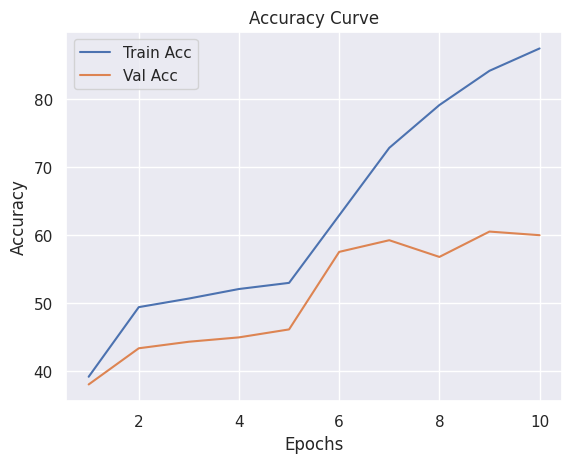

In [25]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_accs) + 1)

plt.plot(epochs, train_accs, label="Train Acc")
plt.plot(epochs, val_accs, label="Val Acc")

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

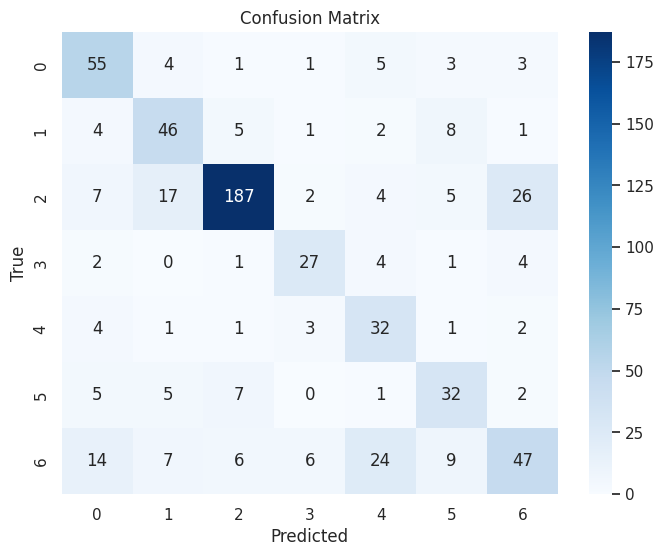

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        out = model(x)
        preds = torch.argmax(out, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

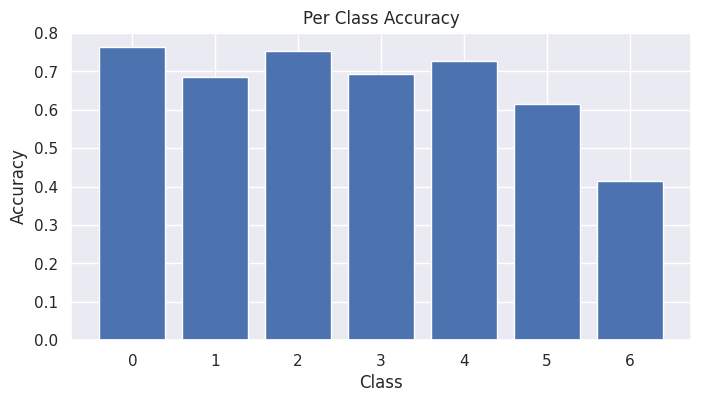

In [27]:
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8,4))
plt.bar(range(len(class_acc)), class_acc)
plt.title("Per Class Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.show()

In [28]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.60      0.76      0.67        72
           1       0.57      0.69      0.63        67
           2       0.90      0.75      0.82       248
           3       0.68      0.69      0.68        39
           4       0.44      0.73      0.55        44
           5       0.54      0.62      0.58        52
           6       0.55      0.42      0.47       113

    accuracy                           0.67       635
   macro avg       0.61      0.67      0.63       635
weighted avg       0.70      0.67      0.67       635



In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# =========================
# CLASS NAMES
# =========================
CLASS_NAMES = {
    0: "Cardboard",
    1: "Clothes",
    2: "Garbage_bag",
    3: "Glass",
    4: "Metal",
    5: "Organic",
    6: "Plastics"
}

# =========================
# TRANSFORM
# =========================
infer_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# =========================
# LOAD MODEL
# =========================
model.load_state_dict(torch.load("best.pth", map_location=DEVICE))
model.to(DEVICE)
model.eval()

# =========================
# INFERENCE FUNCTION (ADVANCED)
# =========================
def predict_image(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")
    orig_image = image.copy()

    # preprocess
    img_tensor = infer_tf(image).unsqueeze(0).to(DEVICE)

    # inference
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1).cpu().numpy()[0]

    # top prediction
    top_idx = np.argmax(probs)
    top_class = CLASS_NAMES[top_idx]
    top_conf = probs[top_idx] * 100

    # top-3 predictions
    top3_idx = np.argsort(probs)[-3:][::-1]
    top3 = [(CLASS_NAMES[i], probs[i]*100) for i in top3_idx]

    # =========================
    # PRINT RESULTS
    # =========================
    print("\n====================")
    print("🔍 Prediction Result")
    print("====================")
    print(f"Class: {top_class}")
    print(f"Confidence: {top_conf:.2f}%\n")

    print("Top 3 Predictions:")
    for c, p in top3:
        print(f"- {c}: {p:.2f}%")

    # =========================
    # SHOW IMAGE
    # =========================
    plt.figure(figsize=(5,5))
    plt.imshow(orig_image)
    plt.title(f"{top_class} ({top_conf:.2f}%)")
    plt.axis("off")
    plt.show()

    return top_class, top_conf, top3


🔍 Prediction Result
Class: Garbage_bag
Confidence: 87.28%

Top 3 Predictions:
- Garbage_bag: 87.28%
- Plastics: 3.80%
- Organic: 2.17%


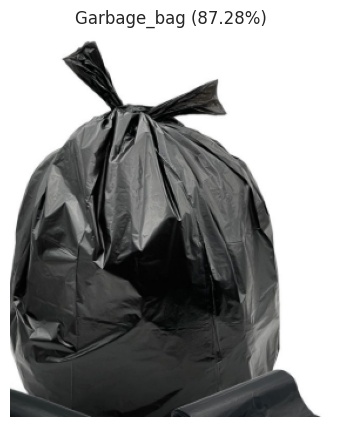

('Garbage_bag',
 np.float32(87.28309),
 [('Garbage_bag', np.float32(87.28309)),
  ('Plastics', np.float32(3.7968733)),
  ('Organic', np.float32(2.172217))])

In [35]:
predict_image("/content/Screenshot 2026-05-12 211218.png")


🔍 Prediction Result
Class: Plastics
Confidence: 32.49%

Top 3 Predictions:
- Plastics: 32.49%
- Clothes: 28.72%
- Garbage_bag: 22.98%


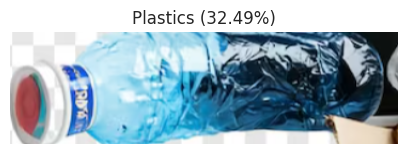

('Plastics',
 np.float32(32.48548),
 [('Plastics', np.float32(32.48548)),
  ('Clothes', np.float32(28.723557)),
  ('Garbage_bag', np.float32(22.976662))])

In [36]:
predict_image("/content/Screenshot 2026-05-12 211405.png")


🔍 Prediction Result
Class: Organic
Confidence: 54.68%

Top 3 Predictions:
- Organic: 54.68%
- Garbage_bag: 24.32%
- Glass: 8.13%


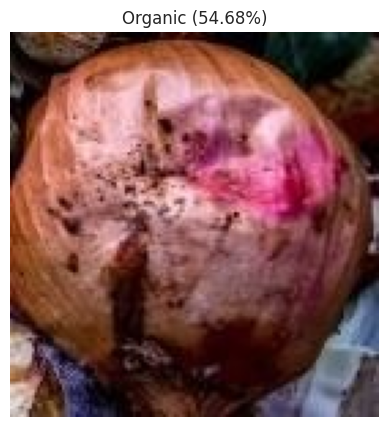

('Organic',
 np.float32(54.67906),
 [('Organic', np.float32(54.67906)),
  ('Garbage_bag', np.float32(24.32245)),
  ('Glass', np.float32(8.130526))])

In [39]:
predict_image("/content/photo_2026-05-12_21-31-19 (2).jpg")


🔍 Prediction Result
Class: Organic
Confidence: 91.13%

Top 3 Predictions:
- Organic: 91.13%
- Garbage_bag: 2.35%
- Plastics: 2.18%


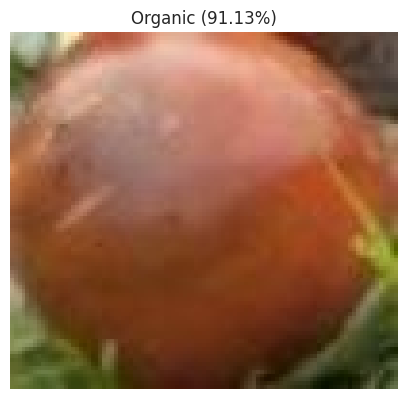

('Organic',
 np.float32(91.13067),
 [('Organic', np.float32(91.13067)),
  ('Garbage_bag', np.float32(2.354688)),
  ('Plastics', np.float32(2.1845193))])

In [41]:
predict_image("/content/photo_2026-05-12_21-31-18 (4).jpg")


🔍 Prediction Result
Class: Plastics
Confidence: 51.50%

Top 3 Predictions:
- Plastics: 51.50%
- Metal: 28.84%
- Garbage_bag: 5.36%


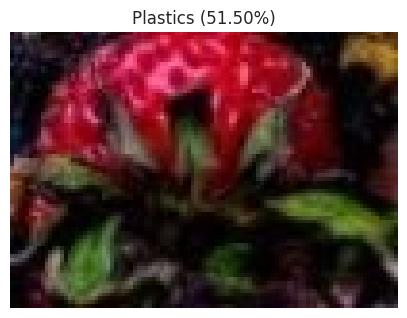

('Plastics',
 np.float32(51.500423),
 [('Plastics', np.float32(51.500423)),
  ('Metal', np.float32(28.837315)),
  ('Garbage_bag', np.float32(5.3620496))])

In [44]:
predict_image("/content/photo_2026-05-12_21-31-18 (3).jpg")


🔍 Prediction Result
Class: Organic
Confidence: 90.50%

Top 3 Predictions:
- Organic: 90.50%
- Plastics: 1.94%
- Garbage_bag: 1.88%


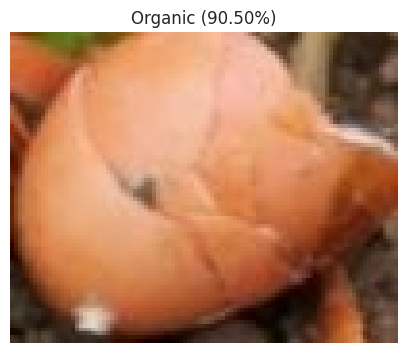

('Organic',
 np.float32(90.503265),
 [('Organic', np.float32(90.503265)),
  ('Plastics', np.float32(1.9435905)),
  ('Garbage_bag', np.float32(1.8785931))])

In [47]:
predict_image("/content/photo_2026-05-12_21-31-15.jpg")


🔍 Prediction Result
Class: Clothes
Confidence: 72.95%

Top 3 Predictions:
- Clothes: 72.95%
- Organic: 12.39%
- Plastics: 3.93%


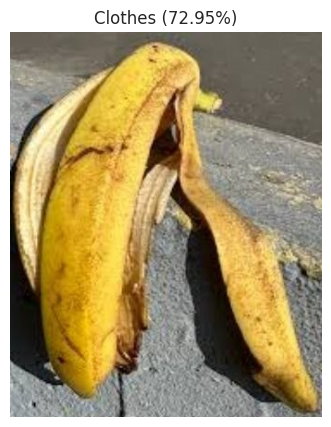

('Clothes',
 np.float32(72.953804),
 [('Clothes', np.float32(72.953804)),
  ('Organic', np.float32(12.390529)),
  ('Plastics', np.float32(3.9302804))])

In [49]:
predict_image("/content/photo_2026-05-12_21-31-15 (2).jpg")